In [34]:
from pathlib import Path
import pandas as pd
import typing as t
import json
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
BASE_DIR = Path("../results/blendsql/hybridqa/validation/")
MODEL_NAME_MAP = {
    "meta-llama_meta-llama-3.1-8b-instruct": "8b",
    "meta-llama_llama-3.2-3b-instruct": "3b",
    "meta-llama_llama-3.2-1b-instruct": "1b",
    "meta-llama_llama-3.3-70b-instruct": "70b",
    "google_gemma-3-12b-it": "12b",
    "llama-3.1-8b-ft_2025-07-21-41:48": "8b-ft-all",
    "meta-llama_llama-3.2-3b-instruct_ft_2025-07-23-00:01": "3b-ft",
    "meta-llama_meta-llama-3.1-8b-instruct_ft_2025-07-23-59:33": "8b-ft",
    "meta-llama_llama-3.2-1b-instruct_ft_program-synthesis_2025-07-24-07:36": "1b-ft"
}

def iter_dir(p: Path):
    for d in p.iterdir():
        if (not d.is_dir() or d.name.startswith('.')):
            continue
        yield d

def load_file(p: Path, filename: str):
    filepath = p / filename
    if not filepath.exists():
        return None
    if filename.endswith(".json"):
        with open(filepath, "r") as f:
            f = json.load(f)
    elif filename.endswith(".csv"):
        f = pd.read_csv(filepath)
    return f

def sort_df_by_cols(df: pd.DataFrame, cols: t.List[str]):
    if isinstance(cols, str):
        cols = [cols]
    for c in cols:
        df.loc[:, f"{c}_numeric"] = df[c].apply(lambda s: int(re.search(r'\d+', s).group()))
    return df.sort_values(by=[f"{c}_numeric" for c in cols])

# Get prompt tokens for each input to hybridqa, in program synthesis mode 
with open("../results/blendsql/hybridqa/validation/generations/guided_grammar/meta-llama_meta-llama-3.1-8b-instruct/generations.json", "r") as f:
    g = json.load(f)

hybridqa_parsing_prompt_tokens = [item['prompt_tokens'] for item in g]

In [36]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("/home/jovyan/model-registry/meta-llama_meta-llama-3.1-8b-instruct")
get_num_tokens = lambda s: len(tokenizer.encode(s))

In [37]:
# Aggregate results to df 
df = []
parsing_model_df = []
parsing_model_to_metric_df = {}
added_parsing_models = set()
for model_dir in iter_dir(BASE_DIR / "baselines"):
    for mode_dir in iter_dir(model_dir):
        metrics = load_file(mode_dir, "metrics.json")
        metric_df = load_file(mode_dir, "metric_df.csv")
        if any(x is None for x in [metrics, metric_df]):
            continue
        if len(metric_df) == 1:
            continue
        existing_keys = metrics['All Predictions']
        if "prompt_tokens" in existing_keys:
            existing_keys.pop("prompt_tokens")
        if "completion_tokens" in existing_keys:
            existing_keys.pop("completion_tokens")
        df.append(
            {
                "execution_model": MODEL_NAME_MAP[model_dir.name],
                "parsing_model": None,
                "exp_name": f"{MODEL_NAME_MAP[model_dir.name]}_{mode_dir.name}",
                "mode": mode_dir.name,
                "avg_execution_prompt_tokens": metric_df['prompt_tokens'].mean(skipna=True) if 'prompt_tokens' in metric_df.columns else -1,
                "avg_execution_completion_tokens": metric_df['completion_tokens'].mean(skipna=True) if 'completion_tokens' in metric_df.columns else -1,
            } | existing_keys
        )

for parsing_model_dir in iter_dir(BASE_DIR / "executions"):
    for execution_model_dir in iter_dir(parsing_model_dir):
        for mode_dir in execution_model_dir.iterdir():
            metrics = load_file(mode_dir, "metrics.json")
            metric_df = load_file(mode_dir, "metric_df.csv")
            if any(x is None for x in [metrics, metric_df]):
                continue
                # raise ValueError(str(mode_dir))
            if len(metric_df) == 1:
                continue
            metric_df['parsing_prompt_tokens'] = hybridqa_parsing_prompt_tokens
            metric_df['parsing_completion_tokens'] = metric_df['response'].apply(lambda s: get_num_tokens(s) if isinstance(s, str) else 0)
            parsing_model = MODEL_NAME_MAP[parsing_model_dir.name]
            execution_model = MODEL_NAME_MAP[execution_model_dir.name]
            existing_keys = metrics['All Predictions']
            if "prompt_tokens" in existing_keys:
                existing_keys.pop("prompt_tokens")
            if "completion_tokens" in existing_keys:
                existing_keys.pop("completion_tokens")
            df.append(
                {
                    "execution_model": execution_model,
                    "parsing_model": parsing_model,
                    "exp_name": f"{parsing_model}_parse_{execution_model}_execute",
                    "mode": mode_dir.name,
                    "avg_parsing_prompt_tokens": metric_df['parsing_prompt_tokens'].mean(skipna=True),
                    "avg_parsing_completion_tokens": metric_df['parsing_completion_tokens'].mean(skipna=True),
                    "avg_execution_prompt_tokens": metric_df['prompt_tokens'].mean(skipna=True) if 'prompt_tokens' in metric_df.columns else -1,
                    "avg_execution_completion_tokens": metric_df['completion_tokens'].mean(skipna=True) if 'completion_tokens' in metric_df.columns else -1,
                } | existing_keys
            )
            if mode_dir.name == "constrained":
                if execution_model == '8b':
                    parsing_model_to_metric_df[parsing_model] = metric_df
                if parsing_model not in added_parsing_models:
                    parsing_model_df.append(
                        {
                            "parsing_model": parsing_model,
                            "executed": metrics['Executed Predictions']['num_examples'] / metrics['All Predictions']['num_examples']
                        }
                    )
                    added_parsing_models.add(parsing_model)

df = pd.DataFrame(df)
df['total_tokens'] = np.nanmean(df[['avg_execution_prompt_tokens', 'avg_execution_completion_tokens', 'avg_parsing_prompt_tokens', 'avg_parsing_completion_tokens']], axis=1)

finetuned_mask = df['exp_name'].str.contains('ft')
finetuned_df = df[finetuned_mask]
prompted_df = df[~finetuned_mask]

parsing_model_df = pd.DataFrame(parsing_model_df)
finetuned_mask = parsing_model_df['parsing_model'].str.contains('ft')
finetuned_parsing_model_df = parsing_model_df[finetuned_mask]
finetuned_parsing_model_df = sort_df_by_cols(finetuned_parsing_model_df, "parsing_model")
prompted_parsing_model_df = parsing_model_df[~finetuned_mask]
prompted_parsing_model_df = sort_df_by_cols(prompted_parsing_model_df, "parsing_model")

/tmp/ipykernel_108670/2025457632.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, f"{c}_numeric"] = df[c].apply(lambda s: int(re.search(r'\d+', s).group()))
/tmp/ipykernel_108670/2025457632.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, f"{c}_numeric"] = df[c].apply(lambda s: int(re.search(r'\d+', s).group()))


In [38]:
sns.set_palette("Spectral")
# Set the default font family
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

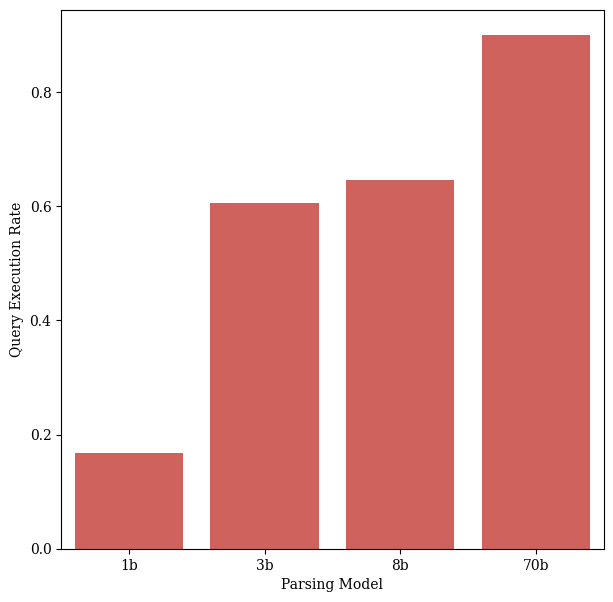

In [39]:
fig, ax = plt.subplots(figsize=(7, 7))
sns.barplot(prompted_parsing_model_df, x="parsing_model", y="executed")
plt.xlabel("Parsing Model")
plt.ylabel("Query Execution Rate")
plt.savefig("img/prompted_query_execution_rates.pdf", bbox_inches='tight') 

In [40]:
prompted_df.sort_values(by="metric_denotation_acc", ascending=False)

,execution_model,parsing_model,exp_name,mode,avg_execution_prompt_tokens,avg_execution_completion_tokens,num_examples,metric_acc,metric_f1,metric_denotation_acc,avg_parsing_prompt_tokens,avg_parsing_completion_tokens,total_tokens
7,70b,None,70b_baseline,baseline,-1.000000,-1.000000,1000,0.545,0.635502,0.578,NaN,NaN,-1.000000
54,8b,70b,70b_parse_8b_execute,constrained,674.457175,7.358176,1000,0.470,0.538101,0.502,3009.098,46.430,934.335838
56,8b,70b,70b_parse_8b_execute,guided_grammar_constrained,662.942761,6.661055,1000,0.469,0.536457,0.499,3009.098,46.576,931.319454
57,8b,70b,70b_parse_8b_execute,unconstrained,686.339817,6.447368,1000,0.431,0.492750,0.459,3009.098,46.430,937.078796
1,8b,None,8b_baseline,baseline,1898.349699,6.871743,1000,0.438,0.509769,0.456,NaN,NaN,952.610721
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,3b,1b,1b_parse_3b_execute,no-predicate-guide,293.957576,7.703030,1000,0.004,0.005452,0.004,3009.098,141.335,863.023402
40,8b,1b,1b_parse_8b_execute,no-predicate-guide,294.260606,9.860606,1000,0.004,0.005301,0.004,3009.098,141.335,863.638553
48,1b,1b,1b_parse_1b_execute,constrained,519.431138,17.634731,1000,0.002,0.003452,0.002,3009.098,141.335,921.874717
50,1b,1b,1b_parse_1b_execute,unconstrained,294.757576,7.466667,1000,0.000,0.001619,0.000,3009.098,141.335,863.164311


In [25]:
finetuned_df.sort_values(by="metric_denotation_acc", ascending=False)

,execution_model,parsing_model,exp_name,mode,avg_execution_prompt_tokens,avg_execution_completion_tokens,num_examples,metric_acc,metric_f1,metric_denotation_acc,avg_parsing_prompt_tokens,avg_parsing_completion_tokens,total_tokens
43,8b,8b-ft,8b-ft_parse_8b_execute,constrained,619.089404,5.916115,1000,0.468,0.535112,0.501,3009.098,44.425,919.632130
44,8b-ft,8b-ft,8b-ft_parse_8b-ft_execute,constrained,619.154525,6.630243,1000,0.453,0.510079,0.478,3009.098,44.425,919.826942
57,8b,3b-ft,3b-ft_parse_8b_execute,constrained,626.536476,6.406285,1000,0.436,0.502328,0.474,3009.098,43.727,921.441940
58,3b-ft,3b-ft,3b-ft_parse_3b-ft_execute,constrained,627.221100,5.319865,1000,0.390,0.463118,0.433,3009.098,43.727,921.341491
8,8b,8b-ft-all,8b-ft-all_parse_8b_execute,constrained,585.128329,5.532688,1000,0.372,0.430990,0.407,3009.098,51.116,912.718754
59,8b,1b-ft,1b-ft_parse_8b_execute,constrained,614.134931,6.447667,1000,0.351,0.403079,0.374,3009.098,46.373,919.013399
60,1b-ft,1b-ft,1b-ft_parse_1b-ft_execute,constrained,614.179067,6.824716,1000,0.091,0.128871,0.097,3009.098,46.373,919.118696


/tmp/ipykernel_108670/646573385.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['score_diff'] = 0
/tmp/ipykernel_108670/646573385.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.    -0.003 -0.016]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  subset.loc[subset['parsing_model'] == parsing_model, 'score_diff'] = subset[subset['parsing_model'] == parsing_model][use_metric] - base_score
/tmp/ipykernel_108670/2025457632.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

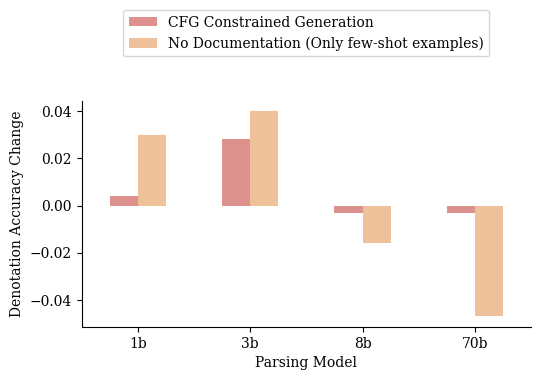

In [41]:
use_metric = "metric_denotation_acc"

subset = prompted_df[(prompted_df['mode'].isin(['constrained', 'guided_grammar_constrained', 'no_documentation_constrained'])) & (prompted_df['execution_model'] == '8b')]
subset['score_diff'] = 0
for parsing_model in subset['parsing_model'].unique():
    base_score = subset[(subset['parsing_model'] == parsing_model) & (subset['mode'] == 'constrained')].iloc[0][use_metric]
    subset.loc[subset['parsing_model'] == parsing_model, 'score_diff'] = subset[subset['parsing_model'] == parsing_model][use_metric] - base_score
subset = sort_df_by_cols(subset, 'parsing_model')
subset = subset[subset['parsing_model'] != '12b']
subset = subset[subset['mode'] != 'constrained']
subset['mode'] = subset['mode'].replace({"no_documentation_constrained": "No Documentation (Only few-shot examples)", "guided_grammar_constrained": "CFG Constrained Generation"})
g = sns.catplot(subset, kind="bar",
    x="parsing_model", y="score_diff",
    hue="mode", width=0.5,
    alpha=.7, height=3, aspect=2,
)
g.set_xlabels("Parsing Model")
g.set_ylabels("Denotation Accuracy Change")
g._legend.set(visible=False)
plt.legend(loc='center', bbox_to_anchor=(0.5, 1.3))

In [12]:
subset = sort_df_by_cols(df, 'execution_model')[['execution_model', 'parsing_model', 'mode', 'metric_denotation_acc']]
subset[~subset['mode'].isin(['no-predicate-guide', 'unconstrained', 'baseline-no-context'])].to_csv("all_performance.csv")

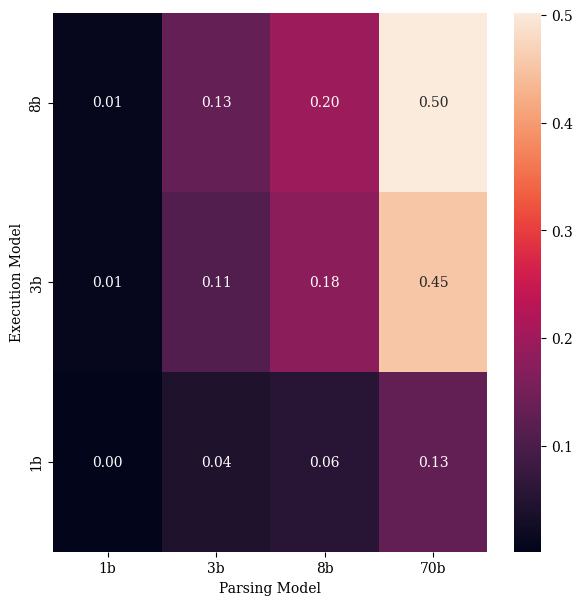

In [42]:
fig, ax = plt.subplots(figsize=(7, 7))
subset = prompted_df[~pd.isna(prompted_df['parsing_model']) & (prompted_df['mode'] == 'constrained')]
subset = subset.pivot(index="execution_model", columns="parsing_model", values="metric_denotation_acc")
subset = subset.reindex(columns=sorted(subset.columns, key = lambda x: int(re.search('\d+', x).group())))
subset = subset.reindex(index=sorted(subset.index, key = lambda x: int(re.search('\d+', x).group()), reverse=True))
sns.heatmap(subset, annot=True, fmt=".2f")
plt.xlabel("Parsing Model")
plt.ylabel("Execution Model")
plt.savefig("img/denotation_accuracy_heatmap.pdf", bbox_inches='tight')

/tmp/ipykernel_108670/2025457632.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, f"{c}_numeric"] = df[c].apply(lambda s: int(re.search(r'\d+', s).group()))
/tmp/ipykernel_108670/2025457632.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, f"{c}_numeric"] = df[c].apply(lambda s: int(re.search(r'\d+', s).group()))


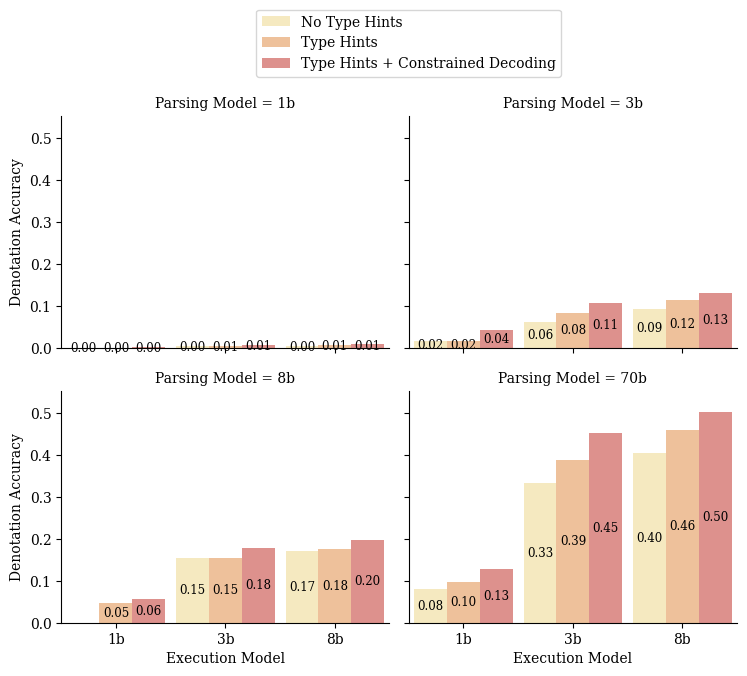

In [43]:
# 2nd version 
sns.set_palette("Spectral")

subset = prompted_df[(prompted_df['mode'].isin(['constrained', 'unconstrained', 'no-predicate-guide']))]
subset = subset[(prompted_df['parsing_model'] != '1b')]
subset.loc[:, 'mode'] = subset['mode'].replace({"constrained": "Type Hints + Constrained Decoding", "unconstrained": "Type Hints", "no-predicate-guide": "No Type Hints"})
subset = sort_df_by_cols(subset, ["execution_model", "parsing_model"])
subset = subset.rename(columns={"parsing_model": "Parsing Model"})

colorcycle = sns.color_palette("Spectral")
hue_order = ["Type Hints + Constrained Decoding", "Type Hints", "No Type Hints"][::-1]
g = sns.catplot(
    data=subset, 
    x='execution_model', 
    y='metric_denotation_acc', 
    hue='mode', 
    col='Parsing Model', 
    kind='bar', 
    hue_order=hue_order, 
    col_wrap=2,
    width=0.9,
    alpha=.7, height=3, aspect=1.3,
    palette={k: colorcycle[idx] for idx, k in enumerate(hue_order[::-1])}
)
g._legend.set(visible=False)

# iterate through axes
for ax in g.axes.ravel():
    # add annotations
    for c in ax.containers:
        labels = [f'{(v.get_height()):.2f}' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=8.5)
    ax.margins(y=0.1)
    
ax = plt.gca()
g.set_xlabels("Execution Model")
g.set_ylabels("Denotation Accuracy")
plt.legend(loc='center', bbox_to_anchor=(0, 2.5))
plt.savefig("img/type_ablations.pdf", bbox_inches='tight')

## Error Analysis

In [281]:
error_types = {
    'no such column': 'Hallucinated Column',
    'no such function': 'Generic SQLite Syntax',
    'no such table': 'Hallucinated Table',
    'Empty subtable passed to QAIngredient!': 'Empty LLMQA Context',
    'sqlglot.errors.TokenError': 'Tokenization Error',
    'sqlglot.errors.ParseError': 'Generic SQLite Syntax',
    'Expected format `{tablename}.{columnname}`': 'BlendSQL Column Reference Error',
    'no such function: STR_POSITION': 'Generic SQLite Syntax',
    'syntax error': 'Generic SQLite Syntax',
    'CUDA out of memory': 'CUDA OOM',
    'sqlite3.OperationalError': 'Generic SQLite Syntax',
    'out of range for positional args tuple': 'F-String Syntax',
    'but no context was passed to fill!': 'F-String Syntax',
    "Expected ',' or ')' in function arguments.": 'Missing "," or ")"',
    'KeyError': 'Hallucinated Column',
    'Unsupported expression type BlendSQLFunction': 'To fix'
}

def classify_error(row):
    if pd.isna(row['error']):
        return None
    error_end = ''.join(str(row['error']).split('\n')[-10:])
    for k, v in error_types.items():
        if k in error_end:
            if v == 'To fix':
                print(row['question'])
                print(row['response'])
                print(row['question_id'])
                print("\n\n---\n\n")
            return v
    # print(row['error'])
    # print()
    # print(row['response'])
    # print('\n\n-----\n\n')
    return 'Misc.'
            
subset = parsing_model_to_metric_df['8b']
subset['error_classification'] = subset.apply(classify_error, axis=1)

What is the launching year of the Network whose call sign was originally owned by the family of Jean Pouliot ?
SELECT network FROM w 
WHERE call_sign = {{
    LLMQA(
        'What network was originally owned by the family of Jean Pouliot?'
    )
}}

06b36735212d23ac


---


What is the name of the historic African Methodist Episcopal church that was built on land donated by Miss Margaret Collingsworth ?
SELECT church FROM w 
WHERE "city, state" = {{
    LLMQA(
        'In what city and state is the historic African Methodist Episcopal church that was built on land donated by Miss Margaret Collingsworth located?'                
    )
}}
AND dates = {{
    LLMQA(
        'What is the date of the historic African Methodist Episcopal church that was built on land donated by Miss Margaret Collingsworth?'                
    )
}}

07d216522b74f4b4


---


What material is the landmark made of that is on Main Street and in the city named by early Spanish navigators in honor of the Viceroy o

In [280]:
print(subset['error_classification'].value_counts())

error_classification
Empty LLMQA Context                198
Hallucinated Column                 68
Generic SQLite Syntax               41
Misc.                               12
BlendSQL Column Reference Error     10
To fix                              10
Hallucinated Table                   7
Tokenization Error                   6
F-String Syntax                      3
Name: count, dtype: int64


In [191]:
subset['error_classification'].value_counts().sum()

97

In [189]:
subset['error_classification'].value_counts(normalize=True) * 100

error_classification
Empty LLMQA Context                49.484536
Generic SQLite Syntax              13.402062
BlendSQL Column Reference Error    13.402062
Hallucinated Column                11.340206
Tokenization Error                  6.185567
Hallucinated Table                  4.123711
F-String Syntax                     1.030928
Misc.                               1.030928
Name: proportion, dtype: float64

In [188]:
print(subset[subset['error_classification'] == 'Empty LLMQA Context'].iloc[1]['response'])

SELECT {{
    LLMQA(
        'What is the surface area in square kilometers of the district containing {}?', 
        (SELECT location FROM w WHERE name = 'zakimi castle site')
    )
}}


In [23]:
subset

,execution_model,Parsing Model,exp_name,mode,avg_execution_prompt_tokens,avg_execution_completion_tokens,num_examples,metric_acc,metric_f1,metric_denotation_acc,avg_parsing_prompt_tokens,avg_parsing_completion_tokens,total_tokens,execution_model_numeric,parsing_model_numeric
32,1b,1b,1b_parse_1b_execute,Type Hints + Constrained Decoding,515.832335,17.568862,1000,0.002,0.004519,0.003,3009.098,141.335,920.958549,1,1
33,1b,1b,1b_parse_1b_execute,No Type Hints,294.757576,7.466667,1000,0.000,0.001619,0.000,3009.098,141.335,863.164311,1,1
34,1b,1b,1b_parse_1b_execute,Type Hints,521.202454,10.496933,1000,0.000,0.002119,0.001,3009.098,141.335,920.533097,1,1
23,1b,3b,3b_parse_1b_execute,Type Hints + Constrained Decoding,1154.547855,19.181518,1000,0.038,0.058021,0.043,3009.098,94.391,1069.304593,1,3
24,1b,3b,3b_parse_1b_execute,No Type Hints,1033.648515,24.813531,1000,0.009,0.013806,0.012,3009.098,94.391,1040.487762,1,3
25,1b,3b,3b_parse_1b_execute,Type Hints,1156.731788,17.468543,1000,0.018,0.024400,0.021,3009.098,94.391,1069.422333,1,3
14,1b,8b,8b_parse_1b_execute,Type Hints + Constrained Decoding,694.340062,9.437888,1000,0.049,0.072542,0.059,3009.098,81.380,948.563988,1,8
15,1b,8b,8b_parse_1b_execute,No Type Hints,696.517301,15.935986,1000,0.022,0.039484,0.030,3009.098,81.380,950.732822,1,8
16,1b,8b,8b_parse_1b_execute,Type Hints,719.611842,10.100329,1000,0.032,0.051238,0.042,3009.098,81.380,955.047543,1,8
50,1b,12b,12b_parse_1b_execute,Type Hints + Constrained Decoding,458.098504,5.597257,1000,0.089,0.126642,0.104,3009.098,47.946,880.184940,1,12


In [25]:
subset = df[(df['mode'].isin(['constrained', 'unconstrained', 'no-predicate-guide'])) & (df['parsing_model'] != '12b')]

In [21]:
subset[subset['parsing_model'] != '12b']

,execution_model,parsing_model,exp_name,mode,avg_execution_prompt_tokens,avg_execution_completion_tokens,num_examples,metric_acc,metric_f1,metric_denotation_acc,avg_parsing_prompt_tokens,avg_parsing_completion_tokens,total_tokens,execution_model_numeric
8,8b,8b,8b_parse_8b_execute,constrained,694.342636,10.066667,1000,0.182,0.227157,0.198,3009.098,81.380,948.721826,8
9,8b,8b,8b_parse_8b_execute,no-predicate-guide,701.198261,11.370435,1000,0.114,0.148398,0.128,3009.098,81.380,950.761674,8
10,8b,8b,8b_parse_8b_execute,unconstrained,721.000000,10.498355,1000,0.131,0.169371,0.144,3009.098,81.380,955.494089,8
11,3b,8b,8b_parse_3b_execute,constrained,691.071875,9.565625,1000,0.161,0.201846,0.177,3009.098,81.380,947.778875,3
12,3b,8b,8b_parse_3b_execute,no-predicate-guide,702.268293,10.191638,1000,0.103,0.134919,0.116,3009.098,81.380,950.734483,3
13,3b,8b,8b_parse_3b_execute,unconstrained,722.015025,8.826377,1000,0.118,0.152238,0.130,3009.098,81.380,955.329851,3
14,1b,8b,8b_parse_1b_execute,constrained,694.340062,9.437888,1000,0.049,0.072542,0.059,3009.098,81.380,948.563988,1
15,1b,8b,8b_parse_1b_execute,no-predicate-guide,696.517301,15.935986,1000,0.022,0.039484,0.030,3009.098,81.380,950.732822,1
16,1b,8b,8b_parse_1b_execute,unconstrained,719.611842,10.100329,1000,0.032,0.051238,0.042,3009.098,81.380,955.047543,1
17,8b,3b,3b_parse_8b_execute,constrained,1156.438017,17.966942,1000,0.115,0.133568,0.129,3009.098,94.391,1069.473490,8


## Hyperparameter Sweeps

In [23]:
from pathlib import Path

execution_model="meta-llama_meta-llama-3.1-8b-instruct"
parsing_model="meta-llama_llama-3.3-70b-instruct"

BASE_DIR = Path(f"../results/blendsql/hybridqa/validation/executions/hparam_sweep/{parsing_model}/{execution_model}")

In [34]:
hparam_df = []
for llmqa_k_dir in iter_dir(BASE_DIR):
    for llmsearchmap_k_dir in iter_dir(llmqa_k_dir):
        metrics = load_file(llmsearchmap_k_dir, "metrics.json")
        metric_df = load_file(llmsearchmap_k_dir, "metric_df.csv")
        if any(x is None for x in [metrics, metric_df]):
            continue
        existing_keys = metrics['All Predictions']
        if "prompt_tokens" in existing_keys:
            existing_keys.pop("prompt_tokens")
        if "completion_tokens" in existing_keys:
            existing_keys.pop("completion_tokens")
        hparam_df.append(
            {
                "execution_model": MODEL_NAME_MAP[execution_model],
                "parsing_model": MODEL_NAME_MAP[parsing_model],
                "llmqa_k": llmqa_k_dir.name.split("_")[-1],
                "llmsearchmap_k": llmsearchmap_k_dir.name.split("_")[-1],
                "avg_execution_prompt_tokens": metric_df['prompt_tokens'].mean(skipna=True) if 'prompt_tokens' in metric_df.columns else -1,
                "avg_execution_completion_tokens": metric_df['completion_tokens'].mean(skipna=True) if 'completion_tokens' in metric_df.columns else -1,
            } | existing_keys
        )
hparam_df = pd.DataFrame(hparam_df)

In [36]:
hparam_df.sort_values(by="metric_denotation_acc", ascending=False)

,execution_model,parsing_model,llmqa_k,llmsearchmap_k,avg_execution_prompt_tokens,avg_execution_completion_tokens,num_examples,metric_acc,metric_f1,metric_denotation_acc
5,8b,70b,15,5,893.776418,6.688543,1000,0.470,0.538095,0.504
3,8b,70b,15,3,890.873192,6.694105,1000,0.470,0.537429,0.503
4,8b,70b,15,1,887.698554,6.690768,1000,0.469,0.536524,0.503
6,8b,70b,10,3,670.464961,6.671858,1000,0.470,0.539361,0.501
7,8b,70b,10,1,667.285873,6.687430,1000,0.469,0.538456,0.501
8,8b,70b,10,5,673.363737,6.688543,1000,0.469,0.539027,0.501
2,8b,70b,20,5,1114.724138,6.829811,1000,0.465,0.528984,0.499
0,8b,70b,20,3,1111.849833,6.835373,1000,0.465,0.528317,0.498
1,8b,70b,20,1,1108.646274,6.832036,1000,0.464,0.527412,0.498


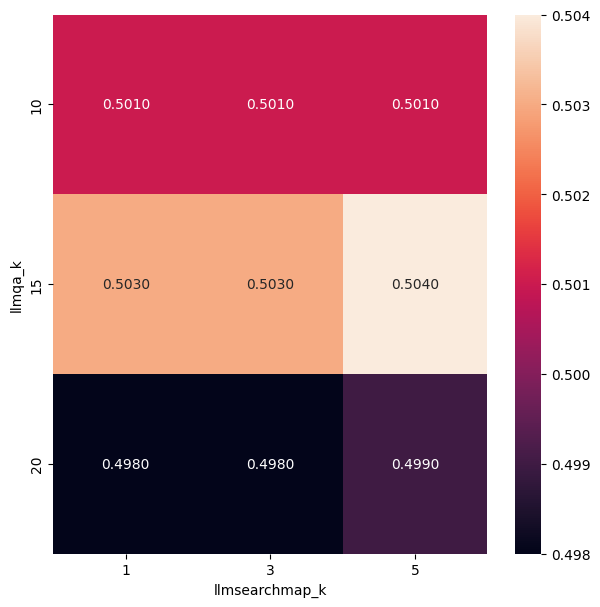

In [37]:
fig, ax = plt.subplots(figsize=(7, 7))
_hparam_df = hparam_df.pivot(index="llmqa_k", columns="llmsearchmap_k", values="metric_denotation_acc")
sns.heatmap(_hparam_df, annot=True, fmt=".4f")
plt.savefig("img/k_hparam_sweep.pdf", bbox_inches='tight')